In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import os
print(os.listdir('/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance'))

['data']


In [7]:
import os

print(os.listdir('/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data'))

['roadaccidents', 'assault', 'vandalism', 'arrest', 'shooting', 'arson', 'explosion', 'normal', 'shoplifting', 'robbery', 'stealing', 'burglary', 'train.csv', 'test.csv', 'abuse', 'fighting']


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Root:", os.listdir('/kaggle/input'))
print("Datasets:", os.listdir('/kaggle/input/datasets'))
print("User folder:", os.listdir('/kaggle/input/datasets/webadvisor'))

print("Inside dataset:",
      os.listdir('/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance'))

print("Inside DATASET:",
      os.listdir('/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data'))

base_path = '/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data'

# Paths
train_csv_path = os.path.join(base_path, 'train.csv')
test_csv_path = os.path.join(base_path, 'test.csv')

train_image_dir = os.path.join(base_path, 'train_images')
test_image_dir = os.path.join(base_path, 'test_images')

#data load
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

# Confirm
print("DATA LOADED SUCCESSFULLY")
print(train_df.shape, test_df.shape)


print(train_df.head())

Root: ['notebooks', 'datasets', 'models']
Datasets: ['webadvisor']
User folder: ['real-time-anomaly-detection-in-cctv-surveillance']
Inside dataset: ['data']
Inside DATASET: ['roadaccidents', 'assault', 'vandalism', 'arrest', 'shooting', 'arson', 'explosion', 'normal', 'shoplifting', 'robbery', 'stealing', 'burglary', 'train.csv', 'test.csv', 'abuse', 'fighting']
DATA LOADED SUCCESSFULLY
(1520, 3) (380, 3)
   Unnamed: 0          label                                    video_name
0        1229         normal        data\normal\Normal_Videos_196_x264.mp4
1         551         normal         data\normal\Normal_Videos179_x264.mp4
2         715         normal         data\normal\Normal_Videos361_x264.mp4
3        1366  roadaccidents  data\roadaccidents\RoadAccidents017_x264.mp4
4         501         normal         data\normal\Normal_Videos125_x264.mp4


# Preprocessing

## Exploratory Data Analysis:
Check the shapes, plot the distribution, extract metadata, read inference

In [9]:
# Basic info
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("\nFirst few rows:")
print(train_df.head())

Train shape: (1520, 3)
Test shape: (380, 3)

Train columns: ['Unnamed: 0', 'label', 'video_name']

First few rows:
   Unnamed: 0          label                                    video_name
0        1229         normal        data\normal\Normal_Videos_196_x264.mp4
1         551         normal         data\normal\Normal_Videos179_x264.mp4
2         715         normal         data\normal\Normal_Videos361_x264.mp4
3        1366  roadaccidents  data\roadaccidents\RoadAccidents017_x264.mp4
4         501         normal         data\normal\Normal_Videos125_x264.mp4


In [10]:
# Check label column
print("\nClass distribution:")
print(train_df['video_name'].value_counts())


Class distribution:
video_name
data\normal\Normal_Videos058_x264.mp4           1
data\normal\Normal_Videos_196_x264.mp4          1
data\normal\Normal_Videos179_x264.mp4           1
data\normal\Normal_Videos361_x264.mp4           1
data\roadaccidents\RoadAccidents017_x264.mp4    1
                                               ..
data\stealing\Stealing084_x264.mp4              1
data\normal\Normal_Videos335_x264.mp4           1
data\normal\Normal_Videos096_x264.mp4           1
data\normal\Normal_Videos458_x264.mp4           1
data\normal\Normal_Videos191_x264.mp4           1
Name: count, Length: 1520, dtype: int64



Missing values:
Unnamed: 0    0
label         0
video_name    0
dtype: int64


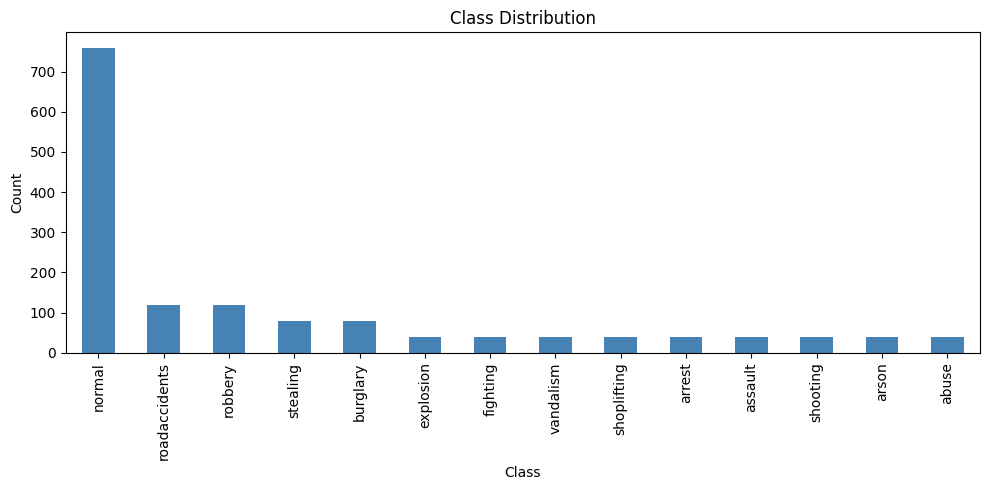

In [11]:
# Check for nulls
print("\nMissing values:")
print(train_df.isnull().sum())

# Visualize class distribution
import matplotlib.pyplot as plt
train_df['label'].value_counts().plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

## Initial Analysis

### Task
Design an AI powered video survelliance system that analyzes real-time CCTV footages to detect and classify unusual events such as violence

### Dataset inference
- mp4 videos of CCTV footages
- Dataset contains 14 different labels, including 13 unusual events
- More detains below

In [12]:
selected_cols = ['label', 'video_name']
train_df = train_df[selected_cols]
test_df = test_df[selected_cols]

total_df = pd.concat([train_df, test_df])
total_df.reset_index(drop = True, inplace = True)
total_df['label'].value_counts()

label
normal           950
roadaccidents    150
robbery          150
stealing         100
burglary         100
explosion         50
fighting          50
vandalism         50
shoplifting       50
arrest            50
assault           50
shooting          50
arson             50
abuse             50
Name: count, dtype: int64

## Proposed approach: 
- We manually watched some videos to understand the dataset in a deeper level
- We found that in the anomaly videos, it's not the entire video that contains anomaly, but a few frames.
- Here is the approach we came up with:

## Visualize random frames

Displaying frames from: /kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/abuse/Abuse038_x264.mp4


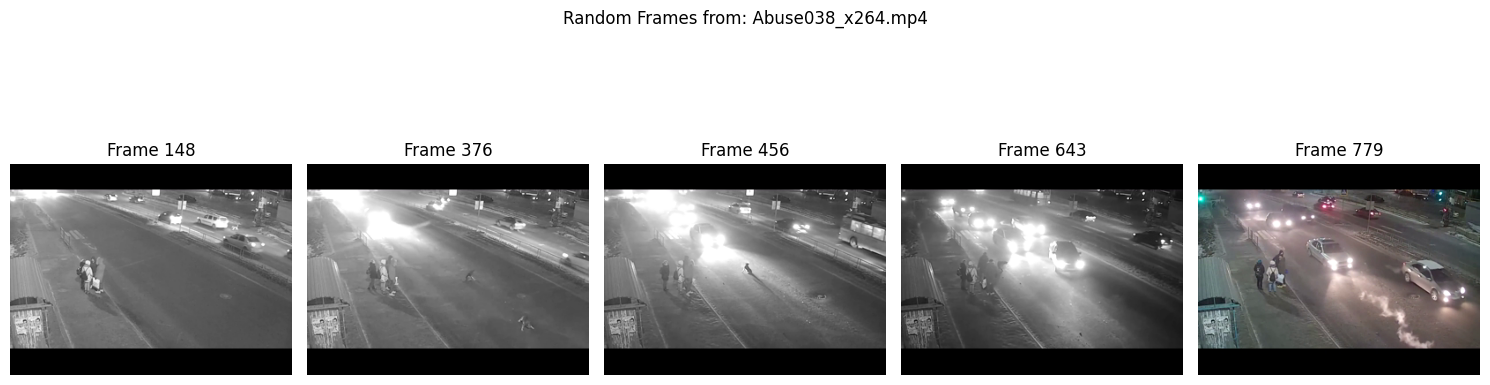

In [14]:
import cv2
import random
import matplotlib.pyplot as plt
import pandas as pd

try:
    df = pd.read_csv('video_manifest.csv')
except FileNotFoundError:
    print("Error: video_manifest.csv not found. Please ensure the 'create_manifest' cell has been run.")
    # Fallback or exit if manifest is critical
    exit()

def display_random_frames(video_path, num_frames=5, figsize=(15, 5)):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Error: No frames found in video {video_path}")
        cap.release()
        return

    # Select random frame indices
    frame_indices = sorted(random.sample(range(total_frames), min(num_frames, total_frames)))

    plt.figure(figsize=figsize)
    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.subplot(1, num_frames, i + 1)
            plt.imshow(frame_rgb)
            plt.title(f"Frame {frame_idx}")
            plt.axis('off')
        else:
            print(f"Warning: Could not read frame {frame_idx} from {video_path}")

    plt.tight_layout()
    plt.suptitle(f"Random Frames from: {video_path.split('/')[-1]}", y=1.02)
    plt.show()
    cap.release()

# Get a random video path from the manifest
random_video_row = df.sample(n=1).iloc[0]
random_video_path = random_video_row['video_path']

print(f"Displaying frames from: {random_video_path}")
display_random_frames(random_video_path, num_frames=5)

## Extracting metadata
Let's understand the dataset more thoroughly

In [13]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

def create_manifest(base_path):
    data = []
    # UCF-Crime structure: base_path/Class_Name/Video_Name.mp4
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    for cls in classes:
        class_path = os.path.join(base_path, cls)
        videos = [f for f in os.listdir(class_path) if f.endswith(('.mp4', '.avi'))]
        
        print(f"Processing class: {cls}")
        for vid in tqdm(videos):
            vid_path = os.path.join(class_path, vid)
            cap = cv2.VideoCapture(vid_path)
            
            if not cap.isOpened():
                continue # Skip corrupt files
                
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            cap.release()
            
            # Map anomaly to 1, normal to 0 for the Binary MVP
            label = 0 if cls.lower() == 'normal' else 1
            
            data.append({
                'video_path': vid_path,
                'class_name': cls,
                'label': label,
                'total_frames': frame_count,
                'fps': fps,
                'segment_size': frame_count // 32
            })
            
    df = pd.DataFrame(data)
    df.to_csv('video_manifest.csv', index=False)
    return df

# Execute
df = create_manifest(base_path)
print(df.head())

Processing class: roadaccidents


100%|██████████| 150/150 [00:03<00:00, 46.01it/s]


Processing class: assault


100%|██████████| 50/50 [00:01<00:00, 44.59it/s]


Processing class: vandalism


...

Processing class: abuse


100%|██████████| 50/50 [00:00<00:00, 51.51it/s]


Processing class: fighting


100%|██████████| 50/50 [00:00<00:00, 53.24it/s]

                                          video_path     class_name  label  \
0  /kaggle/input/datasets/webadvisor/real-time-an...  roadaccidents      1   
1  /kaggle/input/datasets/webadvisor/real-time-an...  roadaccidents      1   
2  /kaggle/input/datasets/webadvisor/real-time-an...  roadaccidents      1   
3  /kaggle/input/datasets/webadvisor/real-time-an...  roadaccidents      1   
4  /kaggle/input/datasets/webadvisor/real-time-an...  roadaccidents      1   

   total_frames   fps  segment_size  
0          1233  30.0            38  
1           918  30.0            28  
2           587  30.0            18  
3          1346  30.0            42  
4          1691  30.0            52  


#### EDA on metadata

In [15]:
df.head(10)

,video_path,class_name,label,total_frames,fps,segment_size
0,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1233,30.0,38
1,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,918,30.0,28
2,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,587,30.0,18
3,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1346,30.0,42
4,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1691,30.0,52
5,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,104,30.0,3
6,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1369,30.0,42
7,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1807,30.0,56
8,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1700,30.0,53
9,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,1213,30.0,37


In [16]:
df.tail(10)

,video_path,class_name,label,total_frames,fps,segment_size
1890,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,1550,30.0,48
1891,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,2423,30.0,75
1892,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,1105,30.0,34
1893,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,3851,30.0,120
1894,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,3213,30.0,100
1895,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,4459,30.0,139
1896,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,803,30.0,25
1897,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,961,30.0,30
1898,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,3501,30.0,109
1899,/kaggle/input/datasets/webadvisor/real-time-an...,fighting,1,5865,30.0,183


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_path    1900 non-null   object 
 1   class_name    1900 non-null   object 
 2   label         1900 non-null   int64  
 3   total_frames  1900 non-null   int64  
 4   fps           1900 non-null   float64
 5   segment_size  1900 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 89.2+ KB


In [18]:
df.nsmallest(5, 'total_frames')

,video_path,class_name,label,total_frames,fps,segment_size
5,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,104,30.0,3
145,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,117,30.0,3
161,/kaggle/input/datasets/webadvisor/real-time-an...,assault,1,137,30.0,4
12,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,155,30.0,4
130,/kaggle/input/datasets/webadvisor/real-time-an...,roadaccidents,1,187,30.0,5


In [19]:
df.nlargest(5, 'total_frames')

,video_path,class_name,label,total_frames,fps,segment_size
1282,/kaggle/input/datasets/webadvisor/real-time-an...,normal,0,976503,30.0,30515
996,/kaggle/input/datasets/webadvisor/real-time-an...,normal,0,628020,30.0,19625
1080,/kaggle/input/datasets/webadvisor/real-time-an...,normal,0,441310,30.0,13790
842,/kaggle/input/datasets/webadvisor/real-time-an...,normal,0,235031,30.0,7344
831,/kaggle/input/datasets/webadvisor/real-time-an...,normal,0,192765,30.0,6023


## Inference from current data gathered
Highly imbalanced, while some videos are barely 100 frames, there are almost 1 million frames in few. This shows a very imbalanced dataset. We can't proceed with traditional methodology.

# Feature Extraction and Modelling
using a 3d convolutional model pretrained on rgb imagenet

## -Initial approach (discarded)-
initially we decided to use a visual transformer to extract frames and use CNN(resnet) +LSTM for modelling, but LSTM have short sequence length making it unfit for the task considering the video stats

## New Approach
- We use Multiple Instance Learning (Industry standard for video tasks)
- We use the 3d conv model (I3d resnet trained on rgb_net) for MIL (feature extraction: 32 segments per video) This is the most time taking task.
- Using the extracted features we train the model. The model will be a small MLP that would not take much time to train.

In [20]:
## manually writing model and importing pretrained weights because we cannot find a pretrained model that can be imported to Kaggle

import torch
import torch.nn as nn
import torch.nn.functional as F

class MaxPool3dPad(nn.Module):
    def __init__(self, kernel_size, stride, padding=None):
        super(MaxPool3dPad, self).__init__()
        if padding is None:
            padding = [k // 2 for k in kernel_size]
        self.pad = nn.ConstantPad3d(padding, 0)
        self.pool = nn.MaxPool3d(kernel_size, stride, 0)

    def forward(self, x):
        return self.pool(self.pad(x))

class Unit3d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(1,1,1), stride=(1,1,1), activation_fn=F.relu, use_batch_norm=True, use_bias=False, name='unit_3d'):
        super(Unit3d, self).__init__()
        padding = [k // 2 for k in kernel_size]
        self._out_channels = out_channels
        self._activation_fn = activation_fn
        self._use_batch_norm = use_batch_norm
        self._name = name
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size, stride, padding=tuple(padding), bias=use_bias)
        if self._use_batch_norm:
            self.bn = nn.BatchNorm3d(out_channels, eps=1e-3, momentum=0.01)

    def forward(self, x):
        x = self.conv(x)
        if self._use_batch_norm:
            x = self.bn(x)
        if self._activation_fn is not None:
            x = self._activation_fn(x)
        return x

class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels, name):
        super(InceptionModule, self).__init__()
        self.b0 = Unit3d(in_channels, out_channels[0], kernel_size=[1,1,1], name=name+'/Branch_0/Conv3d_0a_1x1')
        self.b1a = Unit3d(in_channels, out_channels[1], kernel_size=[1,1,1], name=name+'/Branch_1/Conv3d_0a_1x1')
        self.b1b = Unit3d(out_channels[1], out_channels[2], kernel_size=[3,3,3], name=name+'/Branch_1/Conv3d_0b_3x3')
        self.b2a = Unit3d(in_channels, out_channels[3], kernel_size=[1,1,1], name=name+'/Branch_2/Conv3d_0a_1x1')
        self.b2b = Unit3d(out_channels[3], out_channels[4], kernel_size=[3,3,3], name=name+'/Branch_2/Conv3d_0b_3x3')
        self.b3a = MaxPool3dPad(kernel_size=[3,3,3], stride=[1,1,1], padding=(1,1,1,1,1,1))
        self.b3b = Unit3d(in_channels, out_channels[5], kernel_size=[1,1,1], name=name+'/Branch_3/Conv3d_0b_1x1')

    def forward(self, x):
        b0 = self.b0(x)
        b1 = self.b1b(self.b1a(x))
        b2 = self.b2b(self.b2a(x))
        b3 = self.b3b(self.b3a(x))
        return torch.cat([b0, b1, b2, b3], 1)

class InceptionI3d(nn.Module):
    def __init__(self, num_classes=400, in_channels=3):
        super(InceptionI3d, self).__init__()
        self.conv3d_1a_7x7 = Unit3d(in_channels, 64, kernel_size=[7,7,7], stride=[2,2,2], name='Conv3d_1a_7x7')
        self.maxPool3d_2a_3x3 = MaxPool3dPad(kernel_size=[1,3,3], stride=[1,2,2], padding=(0,0,1,1,1,1))
        self.conv3d_2b_1x1 = Unit3d(64, 64, kernel_size=[1,1,1], name='Conv3d_2b_1x1')
        self.conv3d_2c_3x3 = Unit3d(64, 192, kernel_size=[3,3,3], name='Conv3d_2c_3x3')
        self.maxPool3d_3a_3x3 = MaxPool3dPad(kernel_size=[1,3,3], stride=[1,2,2], padding=(0,0,1,1,1,1))
        self.mixed_3b = InceptionModule(192, [64, 96, 128, 16, 32, 32], 'Mixed_3b')
        self.mixed_3c = InceptionModule(256, [128, 128, 192, 32, 96, 64], 'Mixed_3c')
        self.maxPool3d_4a_3x3 = MaxPool3dPad(kernel_size=[3,3,3], stride=[2,2,2], padding=(0,0,1,1,1,1))
        self.mixed_4b = InceptionModule(480, [192, 96, 208, 16, 48, 64], 'Mixed_4b')
        self.mixed_4c = InceptionModule(512, [160, 112, 224, 24, 64, 64], 'Mixed_4c')
        self.mixed_4d = InceptionModule(512, [128, 128, 256, 24, 64, 64], 'Mixed_4d')
        self.mixed_4e = InceptionModule(512, [112, 144, 288, 32, 64, 128], 'Mixed_4e')
        self.mixed_4f = InceptionModule(592, [256, 160, 320, 32, 128, 128], 'Mixed_4f')
        self.maxPool3d_5a_2x2 = MaxPool3dPad(kernel_size=[2,2,2], stride=[2,2,2], padding=(0,0,0,0,0,0))
        self.mixed_5b = InceptionModule(832, [256, 160, 320, 32, 128, 128], 'Mixed_5b')
        self.mixed_5c = InceptionModule(832, [384, 192, 384, 48, 128, 128], 'Mixed_5c') # Corrected input channels from 1024 to 832
        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1)) # Forces output to (B, 1024, 1, 1, 1)

    def forward(self, x):
        for module in self.children():
            if module == self.avg_pool:
                break
            x = module(x)

        x = self.avg_pool(x)
        return x

**Downloading the pretrained weights of rgb imagenet**

In [21]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="CarrotBu/I3d", filename="rgb_imagenet.pt")

print(f"Weights downloaded to: {weights_path}")

rgb_imagenet.pt:   0%|          | 0.00/50.9M [00:00<?, ?B/s]

Weights downloaded to: /root/.cache/huggingface/hub/models--CarrotBu--I3d/snapshots/053e16f1000e60c42f935da17e52817a352df296/rgb_imagenet.pt


In [22]:
def load_i3d_features(model, weights_path):
    checkpoint = torch.load(weights_path, map_location='cuda')
    
    # Filter out the 'logits' layers since we only want features
    # And handle 'module.' prefix if it exists
    cleaned_state_dict = {}
    for k, v in checkpoint.items():
        name = k.replace('module.', '')
        if 'logits' not in name:
            cleaned_state_dict[name] = v
            
    # strict=False allows us to load the backbone even if the 
    # checkpoint has layers our feature-only class doesn't
    msg = model.load_state_dict(cleaned_state_dict, strict=False)
    print(f"Load Status: {msg}")
    return model

# Initialize and Load
i3d = InceptionI3d(num_classes=400, in_channels=3).cuda()
i3d = load_i3d_features(i3d, weights_path)
i3d.eval()

Load Status: _IncompatibleKeys(missing_keys=['conv3d_1a_7x7.conv.weight', 'conv3d_1a_7x7.bn.weight', 'conv3d_1a_7x7.bn.bias', 'conv3d_1a_7x7.bn.running_mean', 'conv3d_1a_7x7.bn.running_var', 'conv3d_2b_1x1.conv.weight', 'conv3d_2b_1x1.bn.weight', 'conv3d_2b_1x1.bn.bias', 'conv3d_2b_1x1.bn.running_mean', 'conv3d_2b_1x1.bn.running_var', 'conv3d_2c_3x3.conv.weight', 'conv3d_2c_3x3.bn.weight', 'conv3d_2c_3x3.bn.bias', 'conv3d_2c_3x3.bn.running_mean', 'conv3d_2c_3x3.bn.running_var', 'mixed_3b.b0.conv.weight', 'mixed_3b.b0.bn.weight', 'mixed_3b.b0.bn.bias', 'mixed_3b.b0.bn.running_mean', 'mixed_3b.b0.bn.running_var', 'mixed_3b.b1a.conv.weight', 'mixed_3b.b1a.bn.weight', 'mixed_3b.b1a.bn.bias', 'mixed_3b.b1a.bn.running_mean', 'mixed_3b.b1a.bn.running_var', 'mixed_3b.b1b.conv.weight', 'mixed_3b.b1b.bn.weight', 'mixed_3b.b1b.bn.bias', 'mixed_3b.b1b.bn.running_mean', 'mixed_3b.b1b.bn.running_var', 'mixed_3b.b2a.conv.weight', 'mixed_3b.b2a.bn.weight', 'mixed_3b.b2a.bn.bias', 'mixed_3b.b2a.bn.runn

InceptionI3d(
  (conv3d_1a_7x7): Unit3d(
    (conv): Conv3d(3, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
    (bn): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (maxPool3d_2a_3x3): MaxPool3dPad(
    (pad): ConstantPad3d(padding=(0, 0, 1, 1, 1, 1), value=0)
    (pool): MaxPool3d(kernel_size=[1, 3, 3], stride=[1, 2, 2], padding=0, dilation=1, ceil_mode=False)
  )
  (conv3d_2b_1x1): Unit3d(
    (conv): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
    (bn): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (conv3d_2c_3x3): Unit3d(
    (conv): Conv3d(64, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (bn): BatchNorm3d(192, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (maxPool3d_3a_3x3): MaxPool3dPad(
    (pad): ConstantPad3d(padding=(0, 0, 1, 1, 1, 1), value=0)
    (pool): MaxPool3d(kernel_size=[1, 

In [23]:
# Check if the manually defined model has worked

# (Batch: 1, Channels: 3, Time: 16, Height: 224, Width: 224)
dummy_input = torch.randn(1, 3, 16, 224, 224).cuda()
with torch.no_grad():
    features = i3d(dummy_input)

print(f"Feature shape: {features.shape}") 
# Expected: [1, 1024, 1, 1, 1]

Feature shape: torch.Size([1, 1024, 1, 1, 1])


In [ ]:
import os
import torch
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm

def load_i3d_backbone(model, weights_path):
    # Load weights onto GPU
    checkpoint = torch.load(weights_path, map_location='cuda')
    
    # Standardize keys (handling 'module.' from DataParallel)
    cleaned_state_dict = {}
    for k, v in checkpoint.items():
        name = k.replace('module.', '')
        # Only keep weights that exist in our backbone definition
        if name in model.state_dict() and 'logits' not in name:
            cleaned_state_dict[name] = v
            
    model.load_state_dict(cleaned_state_dict, strict=False)
    model.cuda().eval()
    return model

def extract_features_from_video(video_path, model, num_segments=32, frames_per_seg=16):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # If video is extremely short, we pad by repeating frames
    if total_frames < frames_per_seg:
        cap.release()
        return None 

    # We want exactly 32 segments
    seg_size = total_frames / num_segments
    video_features = []

    for i in range(num_segments):
        # Calculate the center of the segment
        center_idx = int((i * seg_size) + (seg_size / 2))
        start_frame = max(0, center_idx - (frames_per_seg // 2))
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        frames = []
        for _ in range(frames_per_seg):
            ret, frame = cap.read()
            if not ret:
                # If we run out of frames, repeat the last valid one
                if len(frames) > 0:
                    frames.append(frames[-1])
                break
            
            frame = cv2.resize(frame, (224, 224))
            # I3D standard normalization: [0, 255] -> [-1, 1]
            frame = (frame / 127.5) - 1.0
            frames.append(frame)
        
        if len(frames) < frames_per_seg:
            # Skip segment if it's completely empty/broken
            continue

        input_tensor = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).unsqueeze(0).float().cuda()
        
        with torch.no_grad():
            # Calling model() uses the forward() we defined which ends at avg_pool
            features = model(input_tensor) 
            # Output is [1, 1024, 1, 1, 1], we flatten to [1024]
            video_features.append(features.cpu().numpy().flatten())
            
    cap.release()
    
    if len(video_features) == 0:
        return None
    
    res = np.array(video_features)
    if res.shape[0] < num_segments:
        padding = np.zeros((num_segments - res.shape[0], res.shape[1]))
        res = np.vstack([res, padding])
        
    return res

i3d_model = InceptionI3d(num_classes=400, in_channels=3)

i3d_model = load_i3d_backbone(i3d_model, weights_path)

output_dir = './extracted_features'
os.makedirs(output_dir, exist_ok=True)

# Use your manifest from the previous step
df = pd.read_csv('video_manifest.csv')

for idx, row in tqdm(df.iterrows(), total=len(df)):
    save_name = f"{row['class_name']}_{os.path.basename(row['video_path'])}.npy"
    save_path = os.path.join(output_dir, save_name)
    
    if os.path.exists(save_path):
        continue
        
    feat = extract_features_from_video(row['video_path'], i3d_model)
    
    if feat is not None:
        np.save(save_path, feat)

 35%|███▍      | 663/1900 [27:57<59:02,  2.86s/it]  

### Mid point inference

The code above for **Feature Extraction** is a very time taking process. This would take about an hour or even more.
Till then we will define the next steps:

## Train test split
The received extracted features will be split into training and test data for modelling

## Modelling
We shall then train a MLP classifier on the extracted features

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

features_list = []
labels_list = []
video_names_list = []

print("Loading extracted features...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    # Construct the expected save name
    expected_save_name = f"{row['class_name']}_{os.path.basename(row['video_path'])}_{row['label']}.npy"
    save_path = os.path.join(output_dir, expected_save_name)

    if os.path.exists(save_path):
        try:
            feat = np.load(save_path)
            features_list.append(feat)
            labels_list.append(row['label'])
            video_names_list.append(os.path.basename(row['video_path']))
        except Exception as e:
            print(f"Error loading {save_path}: {e}")
   
# Find the maximum segment_size from the manifest and pad if necessary
max_segment_size = df['segment_size'].max() # from create_manifest

# Pad features to ensure consistent shape. important else errors
padded_features_list = []
for feat in features_list:
    if feat.shape[0] < 32: # Assuming we always want 32 segments
        padding = np.zeros((32 - feat.shape[0], feat.shape[1]))
        padded_feat = np.vstack([feat, padding])
    elif feat.shape[0] > 32:
        padded_feat = feat[:32, :]
    else:
        padded_feat = feat
    padded_features_list.append(padded_feat)


all_features = np.array(padded_features_list)
all_labels = np.array(labels_list)

print(f"Loaded {len(all_features)} video features. Shape: {all_features.shape}")
print(f"Labels shape: {all_labels.shape}")

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    all_features, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class VideoFeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long) # conventionally long for classification

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create Dataset instances
train_dataset = VideoFeatureDataset(X_train, y_train)
test_dataset = VideoFeatureDataset(X_test, y_test)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

In [ ]:
# Create DataLoader instances
batch_size = 3
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")